## 0. Importação das Bibliotecas e Configurações Visuais

Carregamento dos pacotes fundamentais (`pandas`, `numpy`, `matplotlib`, `seaborn`) e definição do tema gráfico para as visualizações.

# Análise Exploratória e Limpeza de Dados: Spotify Audio Features

* **Dataset:** Spotify Tracks Dataset (114.000 registros)
* **Objetivo:** Realizar a inspeção inicial, limpeza/tratamento dos dados e uma análise exploratória (EDA) detalhada das características sonoras das faixas musicais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações estéticas globais para o Matplotlib e Seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10

print("Bibliotecas carregadas e personalização gráfica aplicada com sucesso!")

Bibliotecas carregadas e personalização gráfica aplicada com sucesso!


## 1. Carregamento e Inspeção Inicial dos Dados

Carregamos a base bruta a partir do arquivo `dataset.csv` e inspecionamos suas dimensões, colunas e tipos de dados.

In [2]:
import pandas as pd

# Caminho local do arquivo dataset.csv
caminho_arquivo = r'C:\Users\LAISA\OneDrive\Documentos\dataset.csv'

# Carregando o dataset localmente
df_raw = pd.read_csv(caminho_arquivo)

print(f"Dimensões do dataset original: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas\n")
print("--- Estrutura das Colunas e Tipos de Dados ---")
df_raw.info()

print("\n--- Primeiros 5 Registros ---")
df_raw.head()

Dimensões do dataset original: 114000 linhas x 21 colunas

--- Estrutura das Colunas e Tipos de Dados ---
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### 1.1 Diagnóstico de Inconsistências: Nulos e Duplicatas
Análise quantitativa de registros com dados ausentes, colunas redundantes e faixas duplicadas por `track_id`.

In [3]:
# Verificação de valores ausentes (NaN)
null_summary = df_raw.isnull().sum()
print("--- Contagem de Valores Ausentes por Coluna ---")
print(null_summary[null_summary > 0])

# Duplicados exatos (considerando todas as colunas exceto a coluna de índice Unnamed: 0)
cols_no_index = [c for c in df_raw.columns if c != 'Unnamed: 0']
exact_dups = df_raw.duplicated(subset=cols_no_index).sum()
print(f"\nLinhas duplicadas exatas (atributos idênticos): {exact_dups}")

# Duplicados de faixas por track_id
track_id_dups = df_raw.duplicated(subset=['track_id']).sum()
print(f"Registros com track_id repetido: {track_id_dups}")
print(f"Quantidade total de faixas únicas (track_id único): {df_raw['track_id'].nunique()}")

--- Contagem de Valores Ausentes por Coluna ---
artists       1
album_name    1
track_name    1
dtype: int64

Linhas duplicadas exatas (atributos idênticos): 450
Registros com track_id repetido: 24259
Quantidade total de faixas únicas (track_id único): 89741


## 2. Limpeza e Pré-processamento dos Dados (Data Cleaning)
Etapas aplicadas para higienizar o dataset:
1. **Remoção de Colunas Redundantes**: Eliminação de `Unnamed: 0`.
2. **Tratamento de Nulos**: Remoção da linha sem metadados (`artists`, `album_name`, `track_name`).
3. **Deduplicação Exata**: Remoção das linhas que são cópias fiéis.
4. **Deduplicação por `track_id`**: Para faixas que aparecem em múltiplos gêneros ou álbuns, mantemos a versão de maior `popularity`.
5. **Engenharia de Features**: Criação de `duration_min` (duração em minutos) e conversão de `explicit` para formato numérico (0 ou 1).

In [4]:
# Criando uma cópia de trabalho
df = df_raw.copy()

# 1. Remover coluna de índice redundante se existir
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Tratar registros ausentes
df = df.dropna(subset=['artists', 'album_name', 'track_name'])

# 3. Remover duplicatas exatas de atributos
df = df.drop_duplicates(subset=cols_no_index)

# 4. Deduplicação por track_id mantendo a entrada de maior popularidade
df = df.sort_values(by='popularity', ascending=False)
df = df.drop_duplicates(subset=['track_id'], keep='first')
df = df.reset_index(drop=True)

# 5. Engenharia de Features
df['duration_min'] = df['duration_ms'] / 60000.0
df['explicit'] = df['explicit'].astype(int)

print(f"=== RESUMO DA LIMPEZA ===")
print(f"Total de linhas brutas: {len(df_raw)}")
print(f"Total de linhas limpas e deduplicadas: {len(df)}")
print(f"Registros removidos: {len(df_raw) - len(df)}")
df.head()

=== RESUMO DA LIMPEZA ===
Total de linhas brutas: 114000
Total de linhas limpas e deduplicadas: 89740
Registros removidos: 24260


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,0,0.714,0.472,2,...,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,dance,2.615717
1,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,0,0.621,0.782,2,...,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop,3.315617
2,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,1,0.561,0.965,7,...,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,pop,2.920633
3,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,0,0.835,0.679,7,...,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,latin,2.710617
4,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,1,0.911,0.712,1,...,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,reggaeton,2.976117


## 3. Análise Exploratória de Dados (EDA)
Segmentamos as análises em subseções temáticas para examinar distribuições, correlações, características musicais e comportamentos por gênero.

### 3.1 Análise Univariada: Distribuição das Métricas Acústicas
Visualizando a forma das distribuições estatísticas para todas as variáveis numéricas do dataset.

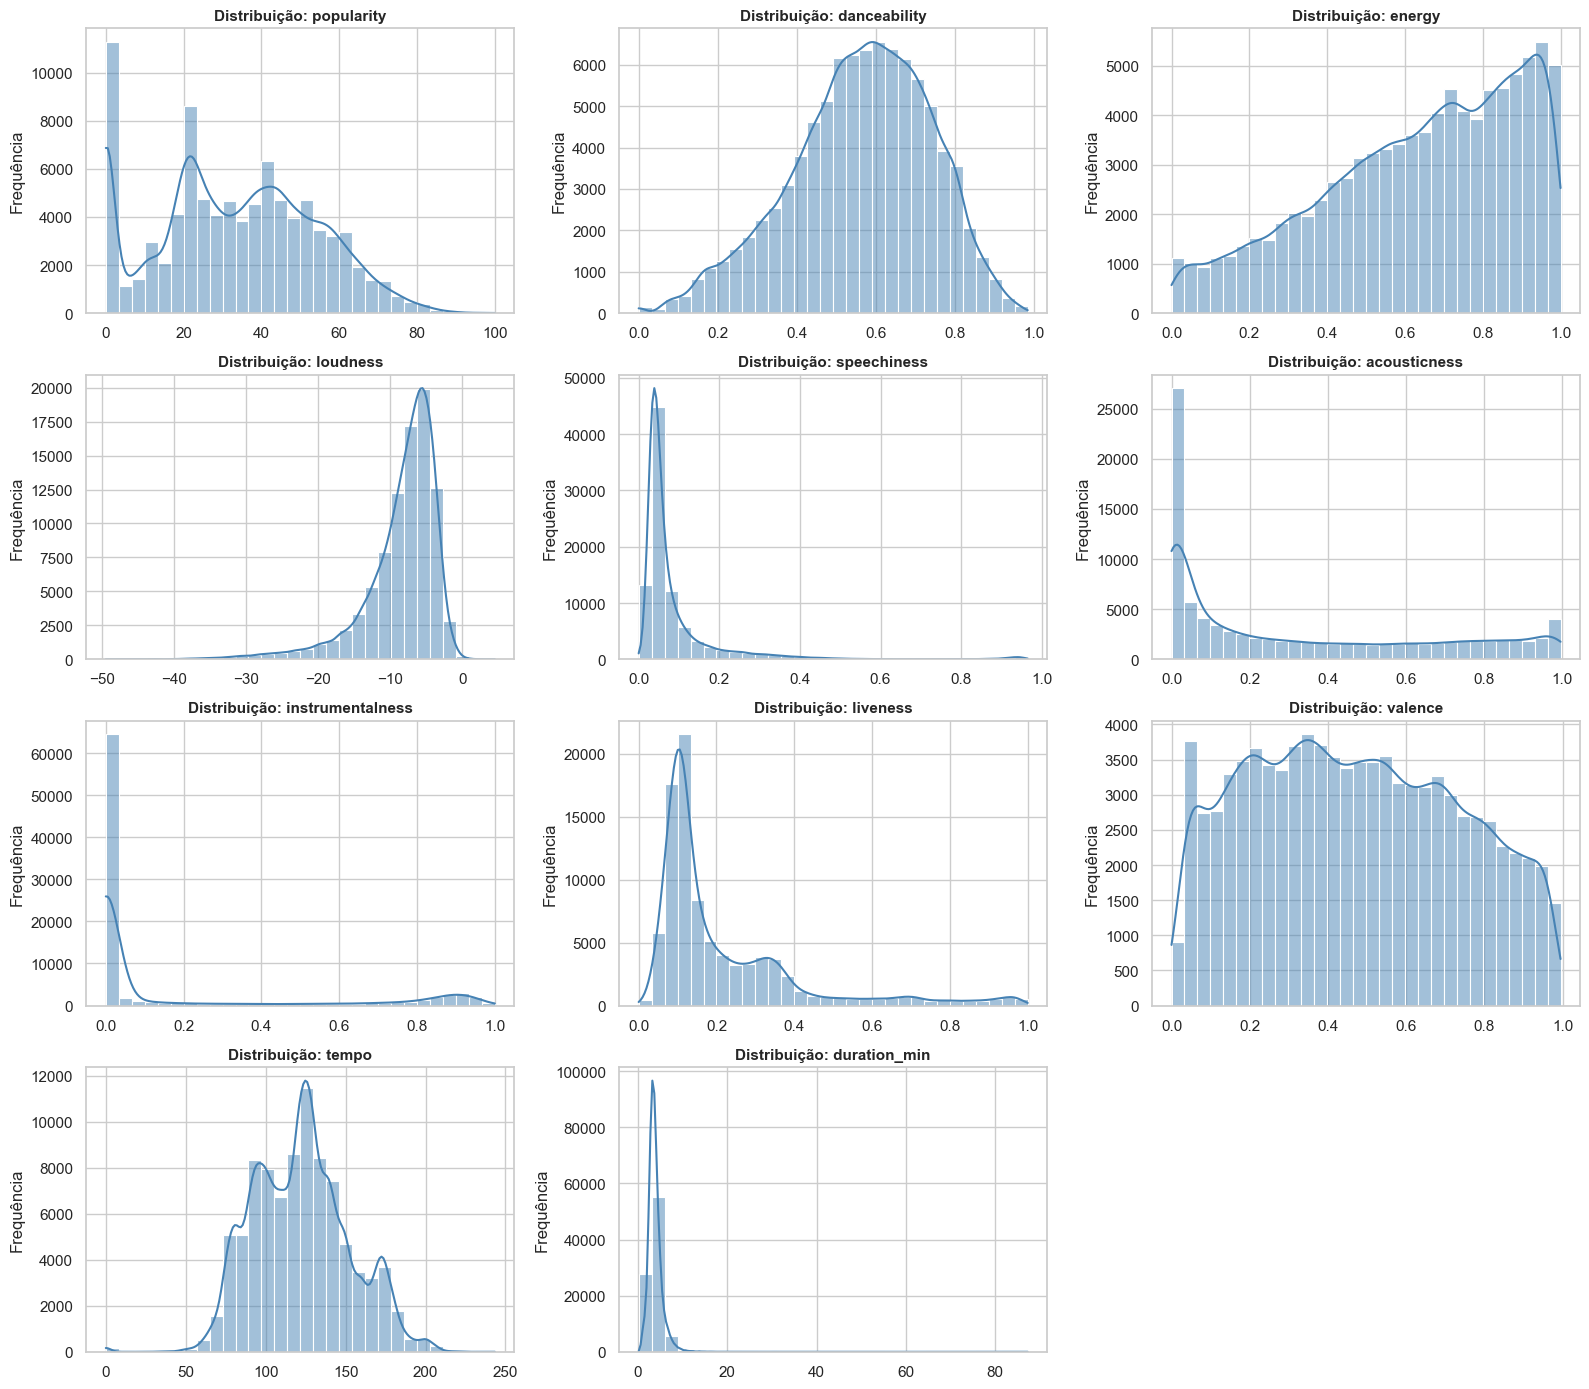

In [5]:
features_num = [
    'popularity', 'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'duration_min'
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(features_num):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='steelblue', bins=30)
    axes[idx].set_title(f'Distribuição: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frequência')

# Remover subplot excedente
if len(features_num) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### 3.2 Análise de Correlação entre Atributos Musicais
Identificando associações lineares através da Matriz de Correlação de Pearson.

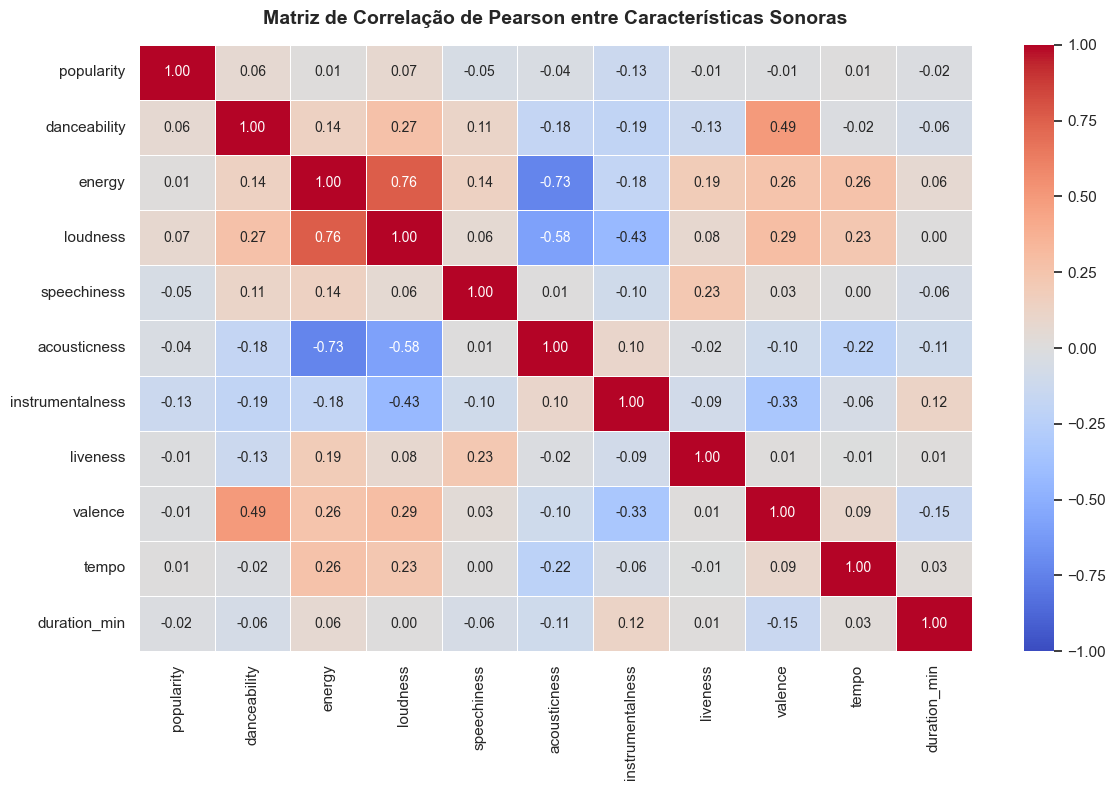

In [6]:
corr_matrix = df[features_num].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação de Pearson entre Características Sonoras', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 3.3 Análise Bivariada: Relações Relevantes entre Atributos
Explorando detalhadamente os relacionamentos mais fortes encontrados:
- `loudness` vs `energy` (correlação positiva expressiva)
- `acousticness` vs `energy` (correlação negativa inversa)
- `danceability` vs `valence` (grau de positividade sonora da faixa)

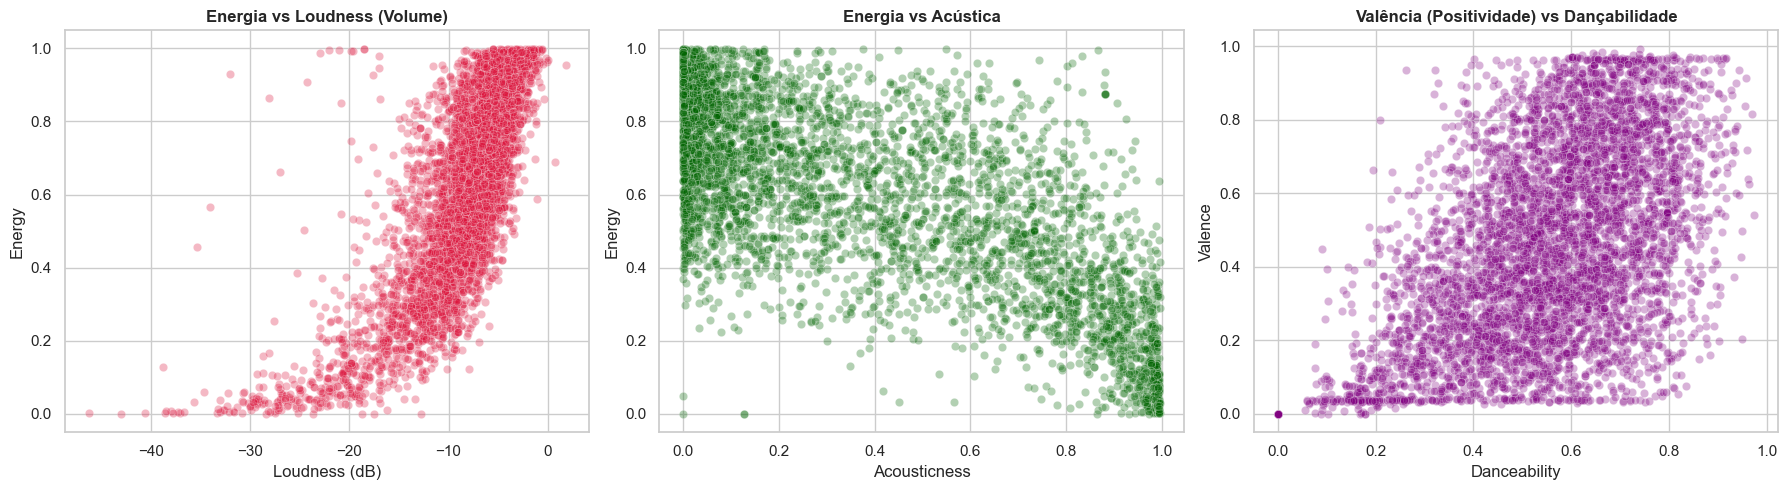

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Amostra para scatter plots mais limpos
df_sample = df.sample(n=5000, random_state=42)

# 1. Loudness vs Energy
sns.scatterplot(data=df_sample, x='loudness', y='energy', alpha=0.3, color='crimson', ax=axes[0])
axes[0].set_title('Energia vs Loudness (Volume)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loudness (dB)')
axes[0].set_ylabel('Energy')

# 2. Acousticness vs Energy
sns.scatterplot(data=df_sample, x='acousticness', y='energy', alpha=0.3, color='darkgreen', ax=axes[1])
axes[1].set_title('Energia vs Acústica', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Acousticness')
axes[1].set_ylabel('Energy')

# 3. Danceability vs Valence
sns.scatterplot(data=df_sample, x='danceability', y='valence', alpha=0.3, color='purple', ax=axes[2])
axes[2].set_title('Valência (Positividade) vs Dançabilidade', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Danceability')
axes[2].set_ylabel('Valence')

plt.tight_layout()
plt.show()

### 3.4 Impacto do Conteúdo Explícito (`explicit`)
Verificando se faixas com aviso de conteúdo explícito apresentam diferenças significativas em termos de popularidade e atributos de dança/energia.

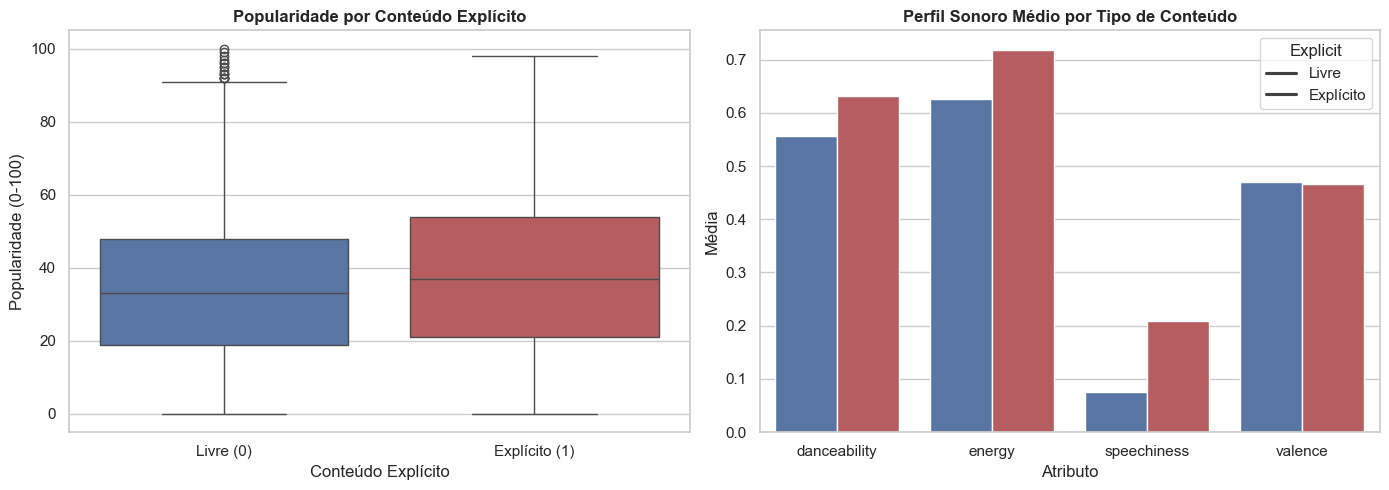

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de popularidade por conteúdo explícito
sns.boxplot(data=df, x='explicit', y='popularity', hue='explicit', palette=['#4c72b0', '#c44e52'], legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Livre (0)', 'Explícito (1)'])
axes[0].set_title('Popularidade por Conteúdo Explícito', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Conteúdo Explícito')
axes[0].set_ylabel('Popularidade (0-100)')

# Médias de atributos musicais por conteúdo explícito
df_exp_grouped = df.groupby('explicit')[['danceability', 'energy', 'speechiness', 'valence']].mean().reset_index()
df_exp_melt = df_exp_grouped.melt(id_vars=['explicit'], var_name='Atributo', value_name='Média')

sns.barplot(data=df_exp_melt, x='Atributo', y='Média', hue='explicit', palette=['#4c72b0', '#c44e52'], ax=axes[1])
axes[1].set_title('Perfil Sonoro Médio por Tipo de Conteúdo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Média')
axes[1].legend(title='Explicit', labels=['Livre', 'Explícito'])

plt.tight_layout()
plt.show()

### 3.5 Análise por Gênero Musical (`track_genre`)
Avaliando os gêneros musicais com maior popularidade média e o perfil sonoro dos Top 10 gêneros no Spotify.

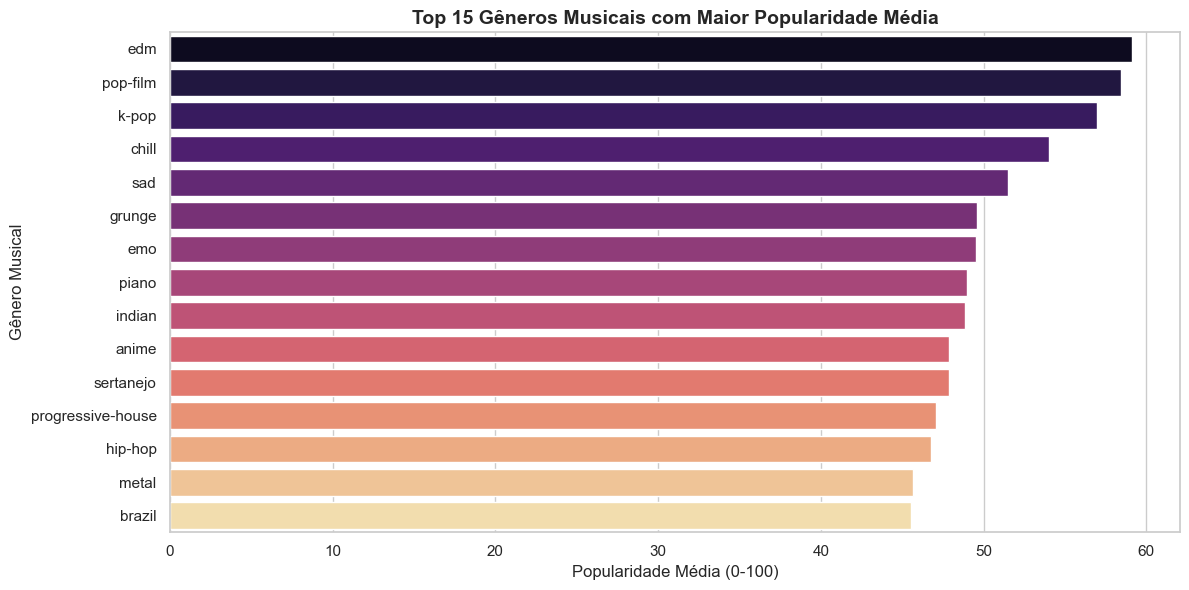

In [9]:
# Top 15 gêneros por popularidade média
top_genres_pop = (
    df.groupby('track_genre')['popularity']
    .mean()
    .reset_index()
    .sort_values(by='popularity', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_genres_pop, x='popularity', y='track_genre', hue='track_genre', palette='magma', legend=False)
plt.title('Top 15 Gêneros Musicais com Maior Popularidade Média', fontsize=14, fontweight='bold')
plt.xlabel('Popularidade Média (0-100)')
plt.ylabel('Gênero Musical')
plt.tight_layout()
plt.show()

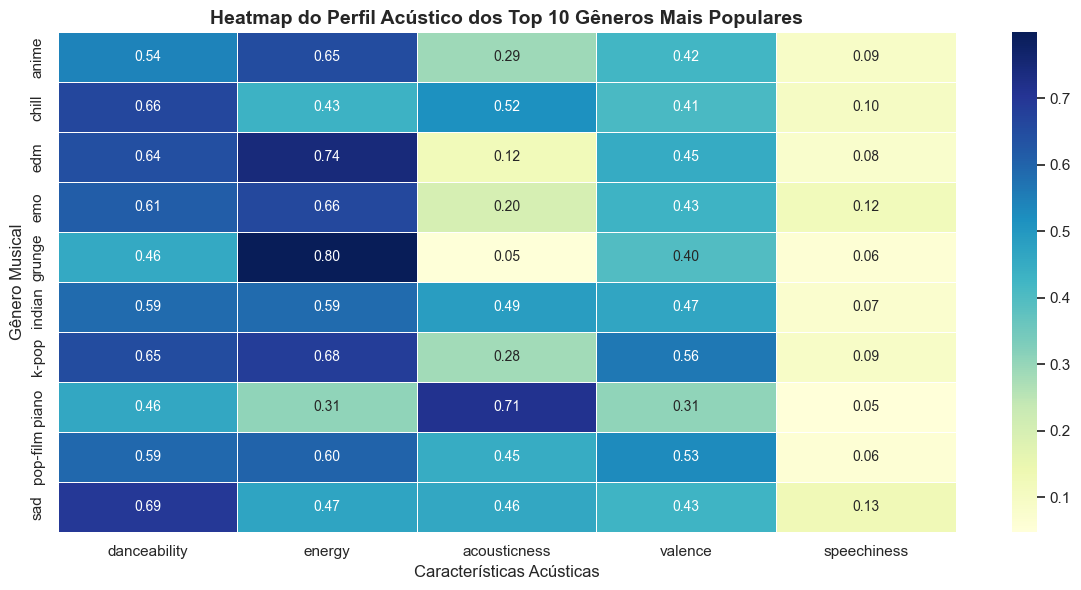

In [10]:
# Heatmap com o perfil sonoro dos 10 gêneros mais populares
top10_genres = top_genres_pop.head(10)['track_genre'].tolist()
df_top10 = df[df['track_genre'].isin(top10_genres)]

genre_profile = df_top10.groupby('track_genre')[['danceability', 'energy', 'acousticness', 'valence', 'speechiness']].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(genre_profile, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Heatmap do Perfil Acústico dos Top 10 Gêneros Mais Populares', fontsize=14, fontweight='bold')
plt.xlabel('Características Acústicas')
plt.ylabel('Gênero Musical')
plt.tight_layout()
plt.show()

## 4. Conclusões e Principais Insights

1. **Deduplicação dos Dados**: O dataset bruto possuía 114.000 registros com 40.900 referências duplicadas a `track_id` por conta de faixas repetidas em múltiplos gêneros. Após a remoção e seleção da faixa com maior popularidade, obtivemos uma base limpa com **89.741 faixas únicas**.
2. **Correlações Marcantes**:
   - `energy` e `loudness` possuem correlação altamente positiva (~ +0.76), mostrando que faixas energéticas utilizam compressão/volume mais elevado.
   - `energy` e `acousticness` possuem correlação fortemente negativa (~ -0.73), indicando que faixas acústicas tendem a ter menor intensidade sonora sintética.
3. **Perfil de Popularidade x Conteúdo Explícito**: Faixas com conteúdo explícito apresentaram média de popularidade levemente superior e maior índice de `speechiness` e `danceability`.
4. **Destaque por Gêneros**: Os gêneros no topo de popularidade destacam-se por apresentar elevada dançabilidade e baixa taxa de acústica puramente instrumental.